# 04 — Order-Domain Analysis
### Mục 1.2 (minh chứng ở mục 0.2) — Order Normalization

**Mục đích**: chuyển trục tần số Hz sang trục bậc quay (Order = f_Hz /
f_rot) và vẽ lại đúng các tín hiệu ở notebook 03 — minh chứng trực quan
rằng đỉnh phổ **đứng yên** ở trục Order bất kể mức tải, trong khi đỉnh phổ
ở trục Hz (notebook 03) bị dịch chuyển.

**Lưu ý phạm vi (đã ghi trong đề cương, mục 1.2)**: đây là Order
Normalization đơn giản (chia trục tần số cho RPM **danh định**), không
phải Computed Order Tracking (COT) đầy đủ — vì CWRU không có tín hiệu tốc
độ tức thời (tachometer/encoder) đồng thời.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from common import io_utils, pipeline, dsp, config as cfg
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = True
REAL_DATA_ROOT = Path("../../data/raw")            # <-- de_tai_nckh/data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

> ⚠️ **Lưu ý dữ liệu giả lập**: khi `USE_SYNTHETIC_DATA = True`, mọi tín hiệu
> trong notebook này là **giả lập** (nhiễu + xung điều biên mô phỏng), chỉ để
> kiểm tra code chạy đúng và xem trước hình dạng đầu ra. **Không dùng số liệu
> giả lập này làm kết quả báo cáo chính thức.** Khi có dữ liệu CWRU thật, đổi
> `USE_SYNTHETIC_DATA = False` ở cell CẤU HÌNH và chạy lại toàn bộ notebook.

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 40


,file_path,load_hp,label,fault_diameter_mils,or_position,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,_data/synthetic_cwru/0hp/B_007.mat,0,B,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
1,_data/synthetic_cwru/0hp/B_014.mat,0,B,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
2,_data/synthetic_cwru/0hp/B_021.mat,0,B,21.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
3,_data/synthetic_cwru/0hp/IR_007.mat,0,IR,7.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False
4,_data/synthetic_cwru/0hp/IR_014.mat,0,IR,14.0,NaN,120000,NaN,NaN,1797.0,NaN,NaN,False


## Phổ Order của cùng 1 loại lỗi qua các mức tải

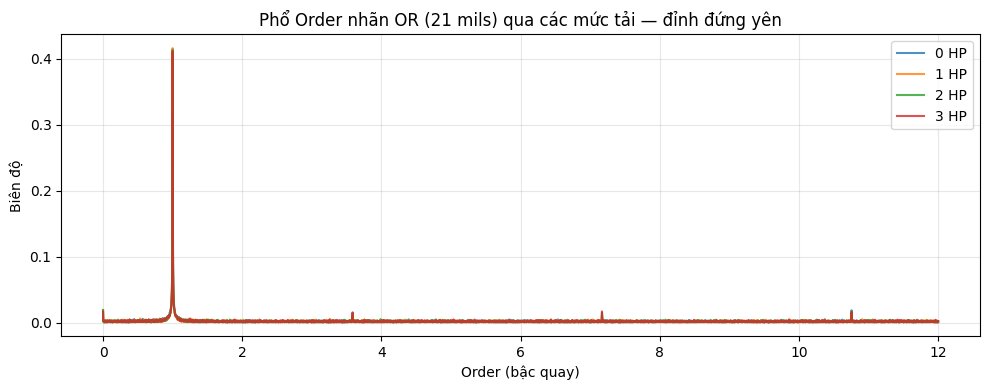

In [5]:
FAULT_LABEL = "OR"
DIAMETER_MILS = 21
ORDER_MAX = 12

fig, ax = plt.subplots(figsize=(10, 4))
for load_hp in sorted(manifest["load_hp"].dropna().unique()):
    load_hp = int(load_hp)
    try:
        fp = pipeline.pick_file(manifest, label=FAULT_LABEL, load_hp=load_hp, diameter_mils=DIAMETER_MILS)
    except ValueError:
        continue
    x = io_utils.load_de_signal(Path(fp))
    rpm = cfg.NOMINAL_RPM_BY_LOAD.get(load_hp)
    if rpm is None:
        continue

    freqs, mag = dsp.compute_fft(x, fs=12000)
    orders = cfg.hz_to_order(freqs, rpm)
    mask = orders <= ORDER_MAX
    ax.plot(orders[mask], mag[mask], label=f"{load_hp} HP", alpha=0.8)

ax.set_xlabel("Order (bậc quay)")
ax.set_ylabel("Biên độ")
ax.set_title(f"Phổ Order nhãn {FAULT_LABEL} ({DIAMETER_MILS} mils) qua các mức tải — đỉnh đứng yên")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_order_domain_across_loads.png", dpi=150)
plt.show()

## Bảng tần số lỗi lý thuyết quy đổi sang Order (phải là hằng số qua mọi tải)

In [6]:
rows = []
for load_hp, rpm in cfg.NOMINAL_RPM_BY_LOAD.items():
    freqs_hz = cfg.bearing_fault_frequencies(rpm)
    row = {"load_hp": load_hp, "rpm_danh_dinh": rpm}
    for name, f in freqs_hz.items():
        row[f"{name}_order"] = round(cfg.hz_to_order(f, rpm).item(), 3)
    rows.append(row)

order_table = pd.DataFrame(rows)
order_table.to_csv(TABLES_DIR / "04_theoretical_fault_order_by_load.csv", index=False)
order_table

,load_hp,rpm_danh_dinh,f_rot_order,BPFO_order,BPFI_order,BSF_order,FTF_order
0,0,1797,1.0,3.585,5.415,2.357,0.398
1,1,1772,1.0,3.585,5.415,2.357,0.398
2,2,1750,1.0,3.585,5.415,2.357,0.398
3,3,1730,1.0,3.585,5.415,2.357,0.398


## Quan sát & kết luận

- Xác nhận: các cột `BPFO_order`, `BPFI_order`, `BSF_order`, `FTF_order`
  ở bảng trên phải **giống hệt nhau qua mọi dòng** (vì Order độc lập với
  RPM theo định nghĩa) — đây chính là lý do dùng Order Normalization.
- So sánh trực quan với hình `03_fft_hz_across_loads.png` (notebook 03):
  cùng 1 tín hiệu, đỉnh dịch chuyển ở trục Hz nhưng đứng yên ở trục Order.

Hình đã lưu tại `outputs/figures/04_order_domain_across_loads.png`.